# Setup

In [1]:
# Import 
import os
import numpy as np
from scipy.spatial import ConvexHull
from scipy.optimize import linear_sum_assignment
from itertools import permutations
import time
import pandas as pd
from joblib import dump, load
from pathlib import Path
from statsmodels.tsa.stattools import adfuller, kpss, acf

## sourceXray
from src.sourceXray_BJ import sourceXray, compute_C, solve_H_right_inverse, log_intrinsic_volume_score
from src.utils import *

## N-FINDR
from src.NFINDR import nfindr_BJ

## LS-NMF
from sklearn.decomposition import NMF

## ESAT
import os
import sys
import json
from esat.data.datahandler import DataHandler
from esat.model.sa import SA
from esat.model.batch_sa import BatchSA
from esat.data.analysis import ModelAnalysis, BatchAnalysis
from esat.estimator import FactorEstimator
from pathlib import Path
from esat.error.bootstrap import Bootstrap
import plotly.io as pio
pio.renderers.default = "browser"

In [2]:
%load_ext autoreload
%autoreload 2

## Plot functions

In [17]:
def plot_C_mean_CI(
    C_mean,
    C_low=None,
    C_high=None,
    title="",
    col_label=None,
    capsize=3,
    savepath=None,
    colors=None,
    ylabel="Expected fraction of elements\nattributable to each source",
    figsize=(10, 5)
):
    """
    Plot grouped bars by source (k) with one bar per feature (j).

    Parameters
    ----------
    C_mean : array-like, shape (K, J)
        Bar heights.
    C_low : array-like, shape (K, J) | None
        Lower bounds of error bars. Must be <= C_mean elementwise.
    C_high : array-like, shape (K, J) | None
        Upper bounds of error bars. Must be >= C_mean elementwise.
    col_label : list[str] | None
        Feature labels of length J. If None -> "Feature 1..J".
    capsize : float
        Error bar cap size (points).
    """
    C_mean = np.asarray(C_mean)
    if C_mean.ndim != 2:
        raise ValueError(f"C_mean must be 2D (K, J); got shape {C_mean.shape}")
    K, J = C_mean.shape

    if (C_low is None) != (C_high is None):
        raise ValueError("Provide both C_low and C_high, or neither.")

    C_low  = np.asarray(C_low)  if C_low  is not None else None
    C_high = np.asarray(C_high) if C_high is not None else None

    if col_label is None:
        labels = [f"Feature {j+1}" for j in range(J)]
    else:
        if len(col_label) != J:
            raise ValueError(f"col_label must have length {J} (got {len(col_label)})")
        labels = list(col_label)

    x = np.arange(K)
    width = 0.8 / max(J, 1)

    fig, ax = plt.subplots(figsize=figsize)

    for j in range(J):
        kwargs = {}
        if C_low is not None:
            yerr_lo = C_mean[:, j] - C_low[:, j]
            yerr_lo = np.maximum(0, yerr_lo)  # prevent negative error bars
            yerr_hi = C_high[:, j] - C_mean[:, j]
            yerr_hi = np.maximum(0, yerr_hi)  # prevent negative error bars
            yerr = np.vstack([yerr_lo, yerr_hi])       # (2, K) for asymmetric bars
            if np.any(np.isfinite(yerr)):
                kwargs["yerr"] = yerr
                kwargs["error_kw"] = {"elinewidth": 1.2, "capsize": capsize}

        if colors is None:
            c = None
        elif isinstance(colors, dict):
            c = colors.get(labels[j], None)
        else:
            c = colors[j]

        ax.bar(
            x + j * width,
            C_mean[:, j],
            width,
            color=c,
            label=labels[j],
            **kwargs,
        )

    ax.set_xticks(x + (J - 1) * width / 2)
    ax.set_xticklabels([f"Source {k+1}" for k in range(K)])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(0, 1)

    ax.legend(title="", loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
    plt.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")
    plt.show()

In [18]:
import matplotlib.dates as mdates
import calendar as calendar

def plot_monthly_W(
    W,
    timestamps,
    columnidx=1,
    covariate=None,                  # array/Series of group labels (len n) or None
    agg="median",
    quantiles=(0.25, 0.75),
    figsize=(9, 4),
    title=None,
    ylabel=None,
    legend_title="Group",
    label_map=None,        # {raw_value: "Nice label"}
    color_map=None,        # {raw_value: "color"}
    linestyle_map=None,    # {raw_value: "linestyle"}
    point_map=None,        # {raw_value: "marker"}
    savepath=None,
):
    """
    Plot MONTHLY time series of one column of W with optional grouping and quantile shading.

    W : ndarray (n, K)  -- rows are observations, columns are sources
    timestamps : pd.Series or array-like of datetimes, length n
    columnidx : int   -- which column of W to plot (0-based)
    covariate : array-like | Series | None
        Optional grouping variable (same length as n). If None, a single overall line is shown.
    agg : {'mean','median'}
    quantiles : tuple[float,float] or None -- e.g., (0.25, 0.75) for IQR shading; None = no band
    """
    import numpy as np, pandas as pd, matplotlib.pyplot as plt

    W = np.asarray(W)
    n, K = W.shape
    if not (0 <= columnidx < K):
        raise ValueError("columnidx out of range for W")

    # timestamps -> Series[datetime64]
    t = pd.Series(pd.to_datetime(timestamps))
    if len(t) != n:
        raise ValueError("timestamps length must match number of rows in W")

    # monthly index (month start timestamps)
    # month = t.dt.to_period("M").dt.to_timestamp()   # e.g., 2023-01-01, 2023-02-01, ...
    month_of_year = t.dt.month  # 1..12

    if covariate is None:
        dfm = pd.DataFrame({
            "value": W[:, columnidx],
            # "month": month,
            "month": month_of_year,
            "group": "All"
        })
    else:
        dfm = pd.DataFrame({
            "value": W[:, columnidx],
            # "month": month,
            "month": month_of_year,
            "group": np.asarray(covariate)
        })

    # aggregate by group x month
    g = dfm.groupby(["group", "month"])["value"]
    center = g.mean() if agg == "mean" else g.median()

    q_lo = q_hi = None
    if quantiles is not None:
        q_lo = g.quantile(quantiles[0])
        q_hi = g.quantile(quantiles[1])

    # make a complete monthly grid from min to max month
    # months = pd.date_range(month.min(), month.max(), freq="MS", name="month")
    months = np.arange(1, 13)

    # reshape to wide (index=month, columns=group)
    center_wide = center.unstack("group").reindex(months)

    if q_lo is not None:
        qlo_wide = q_lo.unstack("group").reindex(months)
        qhi_wide = q_hi.unstack("group").reindex(months)
    else:
        qlo_wide = qhi_wide = None

    # plot
    fig, ax = plt.subplots(figsize=figsize)

    for gval in center_wide.columns:
        label = label_map.get(gval, str(gval)) if label_map is not None else str(gval)
        y = center_wide[gval].values

        linestyle = linestyle_map.get(gval, "-") if linestyle_map is not None else "-"
        marker = point_map.get(gval, "o") if point_map is not None else "o"

        line, = ax.plot(
            months, y,
            marker=marker,
            label=label,
            linestyle=linestyle,
            color=(color_map.get(gval) if color_map is not None and gval in color_map else None),
        )
        line_color = line.get_color()

        # quantile shading
        if qlo_wide is not None and gval in qlo_wide.columns:
            ax.fill_between(
                months,
                qlo_wide[gval].values,
                qhi_wide[gval].values,
                alpha=0.2,
                linewidth=0,
                color=line_color,
            )

    ax.set_ylabel(ylabel or f"W[:, {columnidx}]")
    ax.grid(True, linestyle=":", alpha=0.4)
    if covariate is not None:
        ax.legend(title=legend_title, frameon=False)
    ax.set_title(title or f"Monthly pattern of W[:, {columnidx}]")

    # month labels
    ax.set_xticks(months)
    ax.set_xticklabels([calendar.month_abbr[m] for m in months])

    # # # nicer date ticks
    # # fig.autofmt_xdate()
    # # show months on the x-axis (monthly ticks)
    # ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))     # every month
    # ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))     # 2023-01, 2023-02, ...
    # fig.autofmt_xdate(rotation=45, ha="right")
    
    plt.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")
    plt.show()


## Read data

In [3]:
# GL data 
df_org = pd.read_csv("data/GL_measurements.csv") 
df_org["SampleDate"] = pd.to_datetime(df_org["SampleDate"])
df = df_org.copy()
df["SampleDate"].min(), df["SampleDate"].max()

(Timestamp('2003-05-17 00:00:00'), Timestamp('2016-06-16 00:00:00'))

In [4]:
# Standardize (divide by range to 95th percentile)
Y = df.drop(columns="SampleDate")

scales = {}
for col in Y.columns:
    q0, q95 = np.quantile(Y[col].to_numpy(), [0.0, 0.95])
    iqnr_j = q95 - q0
    scales[col] = iqnr_j
    Y[col] = Y[col]/iqnr_j

scales_df = pd.DataFrame({"params": list(scales.keys()), "scale": list(scales.values())})

In [5]:
col_label = ["Cu", "Ni", "Pb", "S", "Zn", "Al", "Ca", "Cl", "Si", "Ti"]

In [6]:
# row-stochastic Y
r = Y.to_numpy().sum(axis=1, keepdims=True)
Y_star = Y / r

In [7]:
seed = 521
# path 
outdir = Path("results/GL")
outdir.mkdir(parents=True, exist_ok=True)

# Run algorithms

## K = 6

In [8]:
# K = 6
# min_K = 10*K # 11*K (same solution)
# H_star_hat, W_tilde_hat, mu_tilde_hat, Phi_hat, logvol_hat = sourceXray(Y, K, seed=seed, tol=1e-12,
#                                                                         prune=True, min_K=min_K, # for pruning
#                                                                         refine_greedy=True,
#                                                                         verbose=True)[0]
# dump((H_star_hat, W_tilde_hat, mu_tilde_hat, Phi_hat, logvol_hat), outdir / f"GL_scaled_K{K}_minK{min_K}_results.joblib")

In [9]:
# # N-FINDR
# H_star_hat_nfindr, *_ = nfindr_BJ(Y_star, K, max_iter=5, seed=seed, normalize=False, init='atgp')
# W_star_hat_nfindr, _, _ = solve_H_right_inverse(Y_star, H_star_hat_nfindr)
# W_tilde_hat_nfindr = W_star_hat_nfindr * r
# mu_tilde_hat_nfindr = W_tilde_hat_nfindr.mean(axis=0)
# Phi_hat_nfindr = compute_C(mu_tilde_hat_nfindr, H_star_hat_nfindr)
# dump((H_star_hat_nfindr, W_tilde_hat_nfindr, mu_tilde_hat_nfindr, Phi_hat_nfindr), outdir / f"GL_scaled_K{K}_NFINDR_results.joblib")

In [10]:
# # LS-NMF
# nmf_model = NMF(
#     n_components=K,
#     init="nndsvda",          # good default for nonnegative data
#     random_state=seed,   # tie to bootstrap seed for reproducibility
#     max_iter=1000,
#     tol=1e-4
# )

# W_nmf = nmf_model.fit_transform(Y_star)  # shape: (n, K)
# H_nmf = nmf_model.components_            # shape: (K, J)

# ## make H_nmf row-stochastic and adjust W_nmf accordingly 
# H_rs = H_nmf.sum(axis=1, keepdims=True)  # shape (K, 1)
# H_star_hat_lsnmf = H_nmf/H_rs            # each row sums to 1
# W_star_hat_lsnmf = W_nmf*H_rs.T          # scale columns of W_nmf

# ## revert back to original scale
# W_tilde_hat_lsnmf = W_star_hat_lsnmf * r     
# mu_tilde_hat_lsnmf = W_tilde_hat_lsnmf.mean(axis=0)
# Phi_hat_lsnmf = compute_C(mu_tilde_hat_lsnmf, H_star_hat_lsnmf)

# dump((H_star_hat_lsnmf, W_tilde_hat_lsnmf, mu_tilde_hat_lsnmf, Phi_hat_lsnmf), outdir / f"GL_scaled_K{K}_LSNMF_results.joblib")

In [11]:
# # LS-NMF
# nmf_model = NMF(
#     n_components=K,
#     init="nndsvda",          # good default for nonnegative data
#     random_state=seed,   # tie to bootstrap seed for reproducibility
#     max_iter=1000,
#     tol=1e-4, 
#     alpha_W=0.01, 
#     alpha_H=0.01
# )

# W_nmf = nmf_model.fit_transform(Y_star)  # shape: (n, K)
# H_nmf = nmf_model.components_            # shape: (K, J)

# ## make H_nmf row-stochastic and adjust W_nmf accordingly 
# H_rs = H_nmf.sum(axis=1, keepdims=True)  # shape (K, 1)
# H_star_hat_lsnmf = H_nmf/H_rs            # each row sums to 1
# W_star_hat_lsnmf = W_nmf*H_rs.T          # scale columns of W_nmf

# ## revert back to original scale
# W_tilde_hat_lsnmf = W_star_hat_lsnmf * r     
# mu_tilde_hat_lsnmf = W_tilde_hat_lsnmf.mean(axis=0)
# Phi_hat_lsnmf = compute_C(mu_tilde_hat_lsnmf, H_star_hat_lsnmf)

# dump((H_star_hat_lsnmf, W_tilde_hat_lsnmf, mu_tilde_hat_lsnmf, Phi_hat_lsnmf), outdir / f"GL_scaled_K{K}_LSNMF2_results.joblib")

In [12]:
# # ESAT
# # working directory
# cwd = os.getcwd()
# data_dir = os.path.join(cwd, "data")
# output_dir = os.path.join(cwd, "results/GL")

# # Input parameters
# method = "ls-nmf"                   # "ls-nmf", "ws-nmf"
# models = 20                         # the number of models to train
# init_method = "col_means"           # default is column means "col_means", "kmeans", "cmeans"
# init_norm = False                   # if init_method=kmeans or cmeans, normalize the data prior to clustering.
# max_iterations = 20000              # the maximum number of iterations for fitting a model
# converge_delta = 0.01               # convergence criteria for the change in loss, Q
# converge_n = 50                     # convergence criteria for the number of steps where the loss changes by less than converge_delta
# verbose = True                      # adds more verbosity to the algorithm workflow on execution.
# factors = K                         # the number of factors

In [13]:
# %%capture
# GL_data = os.path.join(data_dir, f"GL_measurements_scaled.csv")
# GL_uncertainty = os.path.join(data_dir, f"GL_uncertainty_scaled.csv")
# data_handler = DataHandler(
#     input_path = GL_data,
#     uncertainty_path = GL_uncertainty,
#     index_col = "SampleDate"
# )

# # Get the processed data and uncertainty
# V, U = data_handler.get_data()
# # data_handler.metrics

# # Training multiple models
# sa_models = BatchSA(V=V, U=U, factors=factors, models=models, method=method, 
#                     seed=seed, max_iter=max_iterations,
#                     init_method=init_method, init_norm=init_norm,
#                     converge_delta=converge_delta, converge_n=converge_n,
#                     verbose=verbose)
# _ = sa_models.train()

In [14]:
# best_model = sa_models.best_model
# sa_model = sa_models.results[best_model]
# feature_labels = data_handler.features 

In [15]:
# W_pmf = sa_model.W
# H_pmf = sa_model.H
# mu_pmf = W_pmf.mean(axis=0)
# Phi_hat_pmf = compute_C(mu_pmf, H_pmf)
# H_rs = H_pmf.sum(axis=1, keepdims=True)  # shape (K, 1)
# H_star_hat_pmf = H_pmf/H_rs            # each row sums to 1
# W_tilde_hat_pmf = W_pmf*H_rs.T
# mu_tilde_hat_pmf = W_tilde_hat_pmf.mean(axis=0)
# dump((H_star_hat_pmf, W_tilde_hat_pmf, mu_tilde_hat_pmf, Phi_hat_pmf, sa_model, best_model, feature_labels), 
#      outdir / f"GL_scaled_K{K}_PMF_results.joblib")

## K = 5

In [16]:
# K = 5
# min_K = 20*K
# H_star_hat, W_tilde_hat, mu_tilde_hat, Phi_hat, logvol_hat = sourceXray(Y, K, seed=seed, tol=1e-12,
#                                                                         prune=True, min_K=min_K, # for pruning
#                                                                         refine_greedy=True,
#                                                                         verbose=True)[0]
# dump((H_star_hat, W_tilde_hat, mu_tilde_hat, Phi_hat, logvol_hat), outdir / f"GL_scaled_K{K}_minK{min_K}_results.joblib")

In [33]:
# # N-FINDR
# H_star_hat_nfindr, *_ = nfindr_BJ(Y_star, K, max_iter=5, seed=seed, normalize=False, init='atgp')
# W_star_hat_nfindr, _, _ = solve_H_right_inverse(Y_star, H_star_hat_nfindr)
# W_tilde_hat_nfindr = W_star_hat_nfindr * r
# mu_tilde_hat_nfindr = W_tilde_hat_nfindr.mean(axis=0)
# Phi_hat_nfindr = compute_C(mu_tilde_hat_nfindr, H_star_hat_nfindr)
# dump((H_star_hat_nfindr, W_tilde_hat_nfindr, mu_tilde_hat_nfindr, Phi_hat_nfindr), outdir / f"GL_scaled_K{K}_NFINDR_results.joblib")

In [34]:
# # LS-NMF
# nmf_model = NMF(
#     n_components=K,
#     init="nndsvda",          # good default for nonnegative data
#     random_state=seed,   # tie to bootstrap seed for reproducibility
#     max_iter=1000,
#     tol=1e-4
# )

# W_nmf = nmf_model.fit_transform(Y_star)  # shape: (n, K)
# H_nmf = nmf_model.components_            # shape: (K, J)

# ## make H_nmf row-stochastic and adjust W_nmf accordingly 
# H_rs = H_nmf.sum(axis=1, keepdims=True)  # shape (K, 1)
# H_star_hat_lsnmf = H_nmf/H_rs            # each row sums to 1
# W_star_hat_lsnmf = W_nmf*H_rs.T          # scale columns of W_nmf

# ## revert back to original scale
# W_tilde_hat_lsnmf = W_star_hat_lsnmf * r     
# mu_tilde_hat_lsnmf = W_tilde_hat_lsnmf.mean(axis=0)
# Phi_hat_lsnmf = compute_C(mu_tilde_hat_lsnmf, H_star_hat_lsnmf)

# dump((H_star_hat_lsnmf, W_tilde_hat_lsnmf, mu_tilde_hat_lsnmf, Phi_hat_lsnmf), outdir / f"GL_scaled_K{K}_LSNMF_results.joblib")

In [ ]:
# # LS-NMF
# nmf_model = NMF(
#     n_components=K,
#     init="nndsvda",          # good default for nonnegative data
#     random_state=seed,   # tie to bootstrap seed for reproducibility
#     max_iter=1000,
#     tol=1e-4, 
#     alpha_W=0.01, 
#     alpha_H=0.01
# )

# W_nmf = nmf_model.fit_transform(Y_star)  # shape: (n, K)
# H_nmf = nmf_model.components_            # shape: (K, J)

# ## make H_nmf row-stochastic and adjust W_nmf accordingly 
# H_rs = H_nmf.sum(axis=1, keepdims=True)  # shape (K, 1)
# H_star_hat_lsnmf = H_nmf/H_rs            # each row sums to 1
# W_star_hat_lsnmf = W_nmf*H_rs.T          # scale columns of W_nmf

# ## revert back to original scale
# W_tilde_hat_lsnmf = W_star_hat_lsnmf * r     
# mu_tilde_hat_lsnmf = W_tilde_hat_lsnmf.mean(axis=0)
# Phi_hat_lsnmf = compute_C(mu_tilde_hat_lsnmf, H_star_hat_lsnmf)

# dump((H_star_hat_lsnmf, W_tilde_hat_lsnmf, mu_tilde_hat_lsnmf, Phi_hat_lsnmf), outdir / f"GL_scaled_K{K}_LSNMF2_results.joblib")

['results/GL/GL_scaled_K5_LSNMF2_results.joblib']

In [35]:
# # ESAT
# # working directory
# cwd = os.getcwd()
# data_dir = os.path.join(cwd, "data")
# output_dir = os.path.join(cwd, "results/GL")

# # Input parameters
# method = "ls-nmf"                   # "ls-nmf", "ws-nmf"
# models = 20                         # the number of models to train
# init_method = "col_means"           # default is column means "col_means", "kmeans", "cmeans"
# init_norm = False                   # if init_method=kmeans or cmeans, normalize the data prior to clustering.
# max_iterations = 20000              # the maximum number of iterations for fitting a model
# converge_delta = 0.01               # convergence criteria for the change in loss, Q
# converge_n = 50                     # convergence criteria for the number of steps where the loss changes by less than converge_delta
# verbose = True                      # adds more verbosity to the algorithm workflow on execution.
# factors = K                         # the number of factors

In [36]:
# %%capture
# GL_data = os.path.join(data_dir, f"GL_measurements_scaled.csv")
# GL_uncertainty = os.path.join(data_dir, f"GL_uncertainty_scaled.csv")
# data_handler = DataHandler(
#     input_path = GL_data,
#     uncertainty_path = GL_uncertainty,
#     index_col = "SampleDate"
# )

# # Get the processed data and uncertainty
# V, U = data_handler.get_data()
# # data_handler.metrics

# # Training multiple models
# sa_models = BatchSA(V=V, U=U, factors=factors, models=models, method=method, 
#                     seed=seed, max_iter=max_iterations,
#                     init_method=init_method, init_norm=init_norm,
#                     converge_delta=converge_delta, converge_n=converge_n,
#                     verbose=verbose)
# _ = sa_models.train()

In [37]:
# best_model = sa_models.best_model
# sa_model = sa_models.results[best_model]
# feature_labels = data_handler.features              # The list of feature names/labels

In [38]:
# W_pmf = sa_model.W
# H_pmf = sa_model.H
# mu_pmf = W_pmf.mean(axis=0)
# Phi_hat_pmf = compute_C(mu_pmf, H_pmf)
# H_rs = H_pmf.sum(axis=1, keepdims=True)  # shape (K, 1)
# H_star_hat_pmf = H_pmf/H_rs            # each row sums to 1
# W_tilde_hat_pmf = W_pmf*H_rs.T
# mu_tilde_hat_pmf = W_tilde_hat_pmf.mean(axis=0)
# dump((H_star_hat_pmf, W_tilde_hat_pmf, mu_tilde_hat_pmf, Phi_hat_pmf, sa_model, best_model, feature_labels), 
#      outdir / f"GL_scaled_K{K}_PMF_results.joblib")

# Run bootstrap

In [ ]:
# K = 5
# min_K = 20*K
# K = 6
# min_K = 10*K
# n, J = Y.shape
# n_reps = 100

### PMF

In [20]:
# bootstrap_n = n_reps                                # The number of bootstrap runs to complete
# threshold = 0.6                                     # The r-correlation threshold
# H_star_hat_pmf, W_tilde_hat_pmf, mu_tilde_hat_pmf, C_hat_pmf, sa_model, best_model, feature_labels = load(outdir / f"GL_scaled_K{K}_PMF_results.joblib")

In [21]:
# # Initialize the bootstrap object
# bs = Bootstrap(sa=sa_model, feature_labels=feature_labels, model_selected=best_model, 
#                bootstrap_n=bootstrap_n, block_size=n, threshold=threshold, seed=seed, parallel=True)

In [22]:
# %%time
# # Execute the bootstrap runs with default parameters
# bs.run(block=False)

In [23]:
# dump(bs, outdir / f"Bootstrap/GL_scaled_K{K}_pmf_100bootstraps.joblib")

### Everything

In [ ]:
# methods = ["", "_nfindr", "_lsnmf", "_lsnmf2", "_pmf"]

# results_all = {
#     "seed": np.full(n_reps, np.nan),
#     "W_tilde_hat_mm": np.full((n_reps, 12, K), np.nan), # monthly median of W_tilde_hat

#     **{f"time{m}":                  np.full(n_reps, np.nan)         for m in methods},
#     **{f"logvol{m}":                np.full(n_reps, np.nan)         for m in methods},
#     **{f"Phi_hat{m}":               np.full((n_reps, J, K), np.nan) for m in methods},
#     **{f"H_star_hat{m}":            np.full((n_reps, K, J), np.nan) for m in methods},
#     **{f"mse_by_pollutant{m}":      np.full((n_reps, J), np.nan)    for m in methods},
#     **{f"mse_overall{m}":           np.full(n_reps, np.nan)         for m in methods},
# }

# # reference H 
# H_star = load(outdir/f"GL_scaled_K{K}_minK{min_K}_results.joblib")[0]

# # pmf bootstrap results (different seed than others)
# bs = load(outdir / f"Bootstrap/GL_scaled_K{K}_pmf_100bootstraps.joblib")

In [ ]:
# for rep in range(n_reps):
#     results = load(outdir/f"Bootstrap/v3_K{K}/GL_scaled_K{K}_minK{min_K}_bootstrap_rep{rep+1}.joblib")  
#     seed = results["seed"]
#     results_all["seed"][rep] = seed

#     # to save W_tilde_hat monthly median for each bootstrap replicate
#     rng = np.random.default_rng(seed)
#                                 # resample
#     idx = rng.integers(0, n, size=n)
#     Yb = np.asarray(Y)[idx] 
#     rb = Yb.sum(axis=1, keepdims=True)
#     Yb_star = Yb / rb
#     W_star_hat, _, _ = solve_H_right_inverse(Yb_star, results["H_star_hat"])
#     W_tilde_hat = W_star_hat * rb

#     months_b = pd.to_datetime(df["SampleDate"].to_numpy()[idx]).month

#     Wb = pd.DataFrame(
#         W_tilde_hat,
#         index=pd.Index(months_b, name="month"),
#         columns=[f"src{k+1}" for k in range(W_tilde_hat.shape[1])],
#     )

#     monthly_median = Wb.groupby(level=0).median().reindex(range(1, 13))
#     results_all["W_tilde_hat_mm"][rep] = monthly_median.to_numpy()

#     # save other results
#     for m in methods[0:4]:
#         results_all[f"time{m}"][rep]             = results[f"time{m}"]
#         results_all[f"logvol{m}"][rep]           = results[f"logvol{m}"]
#         results_all[f"Phi_hat{m}"][rep]          = results[f"Phi_hat{m}"]
#         results_all[f"H_star_hat{m}"][rep]       = results[f"H_star_hat{m}"]
#         results_all[f"mse_by_pollutant{m}"][rep] = results[f"mse_by_pollutant{m}"]
#         results_all[f"mse_overall{m}"][rep]      = results[f"mse_overall{m}"]

#     r_v = bs.bs_results[rep+1]
#     idx = r_v["index"]
#     Yb = bs.data[idx]
#     Wb = r_v["model"].W
#     Hb = r_v["model"].H
#     Hb_rs = Hb.sum(axis=1, keepdims=True)  
#     Hb_star = Hb / Hb_rs
#     mub = Wb.mean(axis=0)
#     Phib = compute_C(mub, Hb)
#     logvol_pmf, _ = log_intrinsic_volume_score(Hb_star)
#     H_star_hat_pmf, _, Phi_hat_pmf, _ = permute_estimates_to_match_truth(H_star, Hb_star, mub, Phib)
#     Yhat = Wb @ Hb
#     e_pmf = Yb - Yhat

#     m = methods[4]
#     results_all[f"logvol{m}"][rep]           = logvol_pmf
#     results_all[f"Phi_hat{m}"][rep]          = Phi_hat_pmf
#     results_all[f"H_star_hat{m}"][rep]       = H_star_hat_pmf
#     results_all[f"mse_by_pollutant{m}"][rep] = np.mean(e_pmf**2, axis=0)
#     results_all[f"mse_overall{m}"][rep]      = np.mean(e_pmf**2)
            
# dump(results_all, outdir / f"Bootstrap/GL_scaled_K{K}_minK{min_K}_100bootstraps.joblib")

['results/GL/Bootstrap/GL_scaled_K6_minK60_100bootstraps.joblib']

# Results

## Estimation results (K = 6)

In [39]:
K = 6
min_K = 10*K
H_star_hat, W_tilde_hat, mu_tilde_hat, C_hat, logvol_hat = load(outdir / f"GL_scaled_K{K}_minK{min_K}_results.joblib")
Phi_hat = C_hat.T
Yhat = W_tilde_hat @ H_star_hat
H_star_hat_nfindr, W_tilde_hat_nfindr, mu_tilde_hat_nfindr, C_hat_nfindr = load(outdir / f"GL_scaled_K{K}_NFINDR_results.joblib")
Phi_hat_nfindr = C_hat_nfindr.T
Yhat_nfindr = W_tilde_hat_nfindr @ H_star_hat_nfindr
H_star_hat_lsnmf, W_tilde_hat_lsnmf, mu_tilde_hat_lsnmf, C_hat_lsnmf = load(outdir / f"GL_scaled_K{K}_LSNMF_results.joblib")
Yhat_lsnmf = W_tilde_hat_lsnmf @ H_star_hat_lsnmf
Phi_hat_lsnmf = C_hat_lsnmf.T
H_star_hat_lsnmf2, W_tilde_hat_lsnmf2, mu_tilde_hat_lsnmf2, C_hat_lsnmf2 = load(outdir / f"GL_scaled_K{K}_LSNMF2_results.joblib")
Yhat_lsnmf2 = W_tilde_hat_lsnmf2 @ H_star_hat_lsnmf2
Phi_hat_lsnmf2 = C_hat_lsnmf2.T
H_star_hat_pmf, W_tilde_hat_pmf, mu_tilde_hat_pmf, C_hat_pmf, sa_model, best_model, feature_labels = load(outdir / f"GL_scaled_K{K}_PMF_results.joblib")
Yhat_pmf = W_tilde_hat_pmf @ H_star_hat_pmf
Phi_hat_pmf = C_hat_pmf.T

### GeomNMF

In [41]:
new_order = [3,2,1,0,4,5]

In [43]:
W_df = pd.DataFrame(W_tilde_hat[:,new_order])
W_df.columns=[f"Source {k+1}" for k in range(K)]
W_df["SampleDate"] = df["SampleDate"]

Wstar_df = pd.DataFrame(W_tilde_hat[:,new_order]/r)
Wstar_df.columns=[f"Source {k+1}" for k in range(K)]
Wstar_df["SampleDate"] = df["SampleDate"]

In [45]:
source_cols = [c for c in W_df.columns if c.startswith("Source")]

Source 1: 0.531
Source 2: 0.948
Source 3: 0.177
Source 4: 0.828
Source 5: 0.279
Source 6: 0.610


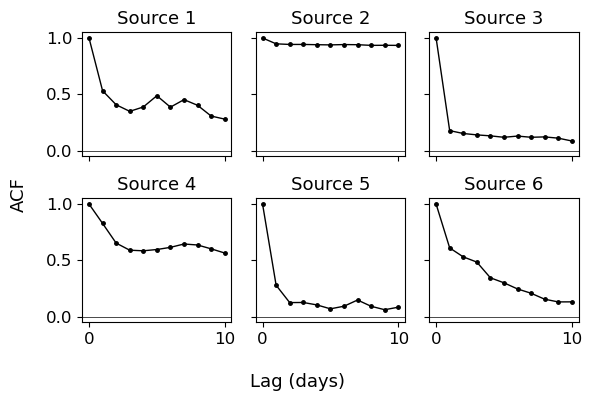

In [ ]:
# ACF
def acf_pairwise(x, nlags):
    """ACF on a regular grid with NaNs, via pairwise deletion.
    Lag k always means k calendar steps because x is on a fixed grid."""
    x = np.asarray(x, float)
    x = x - np.nanmean(x)
    out = [1.0]
    for k in range(1, nlags + 1):
        a, b = x[:-k], x[k:]
        m = ~np.isnan(a) & ~np.isnan(b)
        if m.sum() > 2:
            num = np.sum(a[m] * b[m])
            den = np.sqrt(np.sum(a[m]**2) * np.sum(b[m]**2))
            out.append(num / den if den > 0 else np.nan)
        else:
            out.append(np.nan)
    return np.array(out)

fig, axes = plt.subplots(2, 3, figsize=(6, 4), sharex=True, sharey=True)
axes = axes.ravel()                          # flatten 3x2 -> 6 for zipping
for ax, c in zip(axes, source_cols):
    s = pd.Series(np.asarray(W_df[c], float), index=pd.to_datetime(W_df["SampleDate"]))
    s = s[~s.index.duplicated()].sort_index()
    full = pd.date_range(s.index.min(), s.index.max(), freq="D")
    s = s.reindex(full)
    a = acf_pairwise(s.values, nlags=10)
    print(f"{c}: {a[1]:.3f}")
    ax.plot(range(len(a)), a, marker=".", ms=5, color="black", lw=1)
    ax.axhline(0, color="k", lw=0.5)
    ax.tick_params(labelsize=12)
    ax.set_title(c, fontsize=13)
    # ax.text(0.95, 0.90, rf"$\hat\rho_1={a[1]:.2f}$",
    #         transform=ax.transAxes, ha="right", va="top", fontsize=11)

for ax in axes[len(source_cols):]:           # hide unused panels if <6 sources
    ax.set_visible(False)

fig.supxlabel("Lag (days)", fontsize=13)     # single centered x-label
fig.supylabel("ACF", fontsize=13)
fig.tight_layout()
# fig.savefig(outdir / f"figure/GL_scaled_K{K}_minK{min_K}_lag10acf.pdf")

In [47]:
# W_df.to_csv(outdir / f"GL_scaled_K{K}_minK{min_K}_W_tilde_hat.csv", index=False)

#### Assumption checks 

##### Stationarity

In [48]:
# -------------------------------------------------------------------------------------
# 1. Formal tests for stationary mean: ADF (H0 = unit root) and KPSS (H0 = stationary)
#    Agreement across the two opposite nulls is the convincing case.
# -------------------------------------------------------------------------------------
def formal_tests(x):
    x = pd.Series(x).dropna().values
    adf_p  = adfuller(x, autolag="AIC")[1]
    # KPSS raises for p-values outside its table; clip is fine for reporting
    try:
        kpss_p = kpss(x, regression="c", nlags="auto")[1]
    except Exception:
        kpss_p = np.nan
    return adf_p, kpss_p

rows = []
for c in source_cols:
    adf_p, kpss_p = formal_tests(W_df[c])
    # Reading: ADF small => reject unit root (good); KPSS large => fail to
    # reject stationarity (good). Both pointing to stationary is the clean case.
    verdict = "stationary" if (adf_p < 0.05 and (np.isnan(kpss_p) or kpss_p > 0.05)) \
              else "check"
    rows.append({"source": c, "ADF_p": round(adf_p, 3),
                 "KPSS_p": round(kpss_p, 3) if not np.isnan(kpss_p) else np.nan,
                 "reading": verdict})
tests_table = pd.DataFrame(rows)
print("\n=== ADF / KPSS ===")
print(tests_table.to_string(index=False))

/var/folders/n2/whtt7knd3ld2z521r1w6wvyh0000gn/T/ipykernel_97096/739713416.py:10: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.


/var/folders/n2/whtt7knd3ld2z521r1w6wvyh0000gn/T/ipykernel_97096/739713416.py:10: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.





=== ADF / KPSS ===
  source  ADF_p  KPSS_p    reading
Source 1  0.000   0.010      check
Source 2  0.017   0.100 stationary
Source 3  0.000   0.072 stationary
Source 4  0.000   0.068 stationary
Source 5  0.000   0.100 stationary
Source 6  0.051   0.010      check


/var/folders/n2/whtt7knd3ld2z521r1w6wvyh0000gn/T/ipykernel_97096/739713416.py:10: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.


/var/folders/n2/whtt7knd3ld2z521r1w6wvyh0000gn/T/ipykernel_97096/739713416.py:10: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




##### Probabilistic separability

In [50]:
pd.DataFrame({
    "n": (Wstar_df[source_cols] > 0.8).sum(),
    "pct": (Wstar_df[source_cols] > 0.8).mean().mul(100).round(1),
    "second max": Wstar_df[source_cols].apply(lambda c: c.nlargest(2).iloc[-1]).round(3),
})

,n,pct,second max
Source 1,11,0.5,0.946
Source 2,16,0.8,0.893
Source 3,3,0.1,0.931
Source 4,12,0.6,0.964
Source 5,6,0.3,0.917
Source 6,10,0.5,0.979


### N-FINDR

In [52]:
new_order_nfindr = [2,4,1,5,0,3]

### LS-NMF

In [53]:
new_order_lsnmf = [0,1,3,5,2,4]

### LS-NMF with regularization

In [54]:
new_order_lsnmf2 = [0,5,1,3,2,4]

### PMF

In [55]:
new_order_pmf = [4,0,1,3,5,2]

## Bootstrap uncertainty (K = 6)

In [57]:
methods = ["", "_nfindr", "_lsnmf", "_lsnmf2", "_pmf"]
results_all = load(outdir / f"Bootstrap/GL_scaled_K{K}_minK{min_K}_100bootstraps.joblib")
for m in methods:
    mean_rmse_by_pollutant = np.nanmean(np.sqrt(results_all[f"mse_by_pollutant{m}"]), axis=0)  # shape (J,)
    mean_rmse_overall      = np.nanmean(np.sqrt(results_all[f"mse_overall{m}"]), axis=0)       # scalar
    q025_rmse_overall      = np.nanquantile(np.sqrt(results_all[f"mse_overall{m}"]), 0.025, axis=0)       # scalar
    q975_rmse_overall      = np.nanquantile(np.sqrt(results_all[f"mse_overall{m}"]), 0.975, axis=0)       # scalar

    method_label = m.lstrip("_") if m else "GeomNMF"
    print(f"\n{method_label}")
    print(f"  rmse_overall (95% CI): {mean_rmse_overall:.3f} ({q025_rmse_overall:.3f}, {q975_rmse_overall:.3f})")
    print(f"  rmse_by_pollutant: {mean_rmse_by_pollutant}")


GeomNMF
  rmse_overall (95% CI): 0.272 (0.214, 0.394)
  rmse_by_pollutant: [0.45341516 0.08599515 0.13818637 0.29681029 0.22420304 0.29452449
 0.28675525 0.09230148 0.2483398  0.15521279]

nfindr
  rmse_overall (95% CI): 0.275 (0.214, 0.413)
  rmse_by_pollutant: [0.45806668 0.08310209 0.12908909 0.29193592 0.22920356 0.28932986
 0.27848684 0.09068565 0.24016453 0.18680688]

lsnmf
  rmse_overall (95% CI): 0.264 (0.201, 0.327)
  rmse_by_pollutant: [0.32343272 0.08646843 0.0864015  0.23442152 0.24070399 0.35163366
 0.26877102 0.05203406 0.22920858 0.40319743]

lsnmf2
  rmse_overall (95% CI): 0.300 (0.259, 0.357)
  rmse_by_pollutant: [0.36042929 0.14686524 0.15760316 0.20680052 0.30439671 0.28608887
 0.30266845 0.21651764 0.25326602 0.53056867]

pmf
  rmse_overall (95% CI): 0.668 (0.572, 0.762)
  rmse_by_pollutant: [0.72159175 0.65489064 0.40016527 0.41792083 0.75285746 0.42901448
 0.56063713 0.85918736 0.50956887 1.00610893]


In [58]:
lo, hi = 2.5, 97.5

summary = {}
for m in methods:
    method_label = m.lstrip("_") if m else "GeomNMF"
    summary[method_label] = {}
    for key in ["Phi_hat", "H_star_hat"]:
        arr = results_all[f"{key}{m}"]  # shape (n_reps, J, K) or (n_reps, K, J)
        summary[method_label][key] = {
            "mean": np.nanmean(arr, axis=0),
            "std": np.nanstd(arr, axis=0),
            "low":  np.nanpercentile(arr, lo, axis=0),
            "high": np.nanpercentile(arr, hi, axis=0),
        }

### GeomNMF

#### Assumption checks

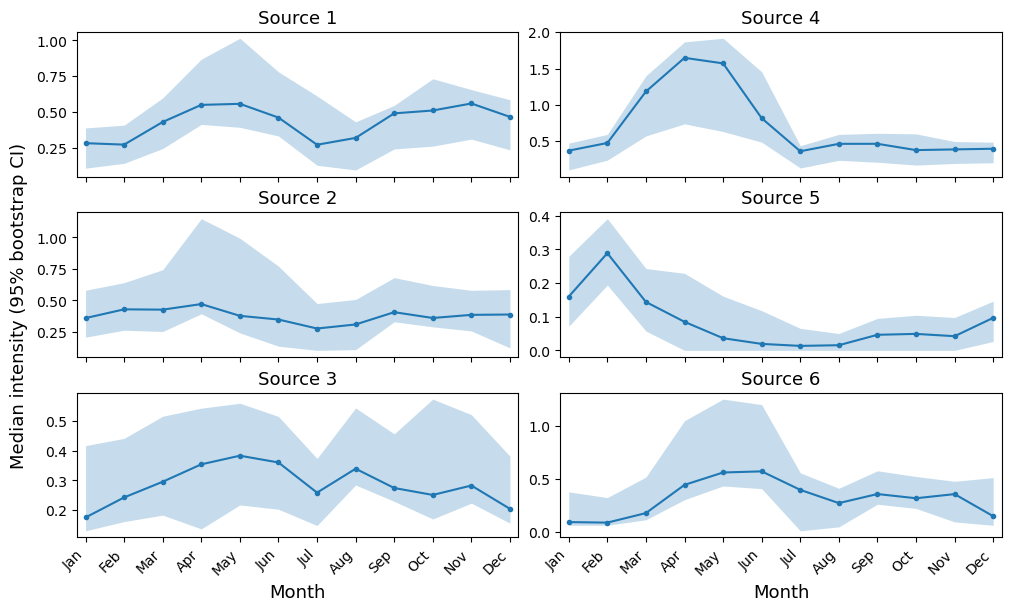

In [ ]:
A = results_all["W_tilde_hat_mm"][:,:,new_order]          # (n_reps, 12, K)
K = A.shape[2]
months = np.arange(1, 13)

median = (
    W_df
    .groupby(pd.to_datetime(W_df["SampleDate"]).dt.month)
    .median(numeric_only=True)
    .reindex(range(1, 13))
    .rename_axis("month")
).to_numpy()
lo, hi = np.nanpercentile(A, [2.5, 97.5], axis=0)

# --- Figure 1: monthly medians ---
fig, axes = plt.subplots(3, 2, figsize=(10, 6), sharex=True, constrained_layout=True)
flat = axes.flatten(order="F")     # 1-3 down the left, 4-6 down the right

for k, ax in enumerate(flat):
    ax.fill_between(months, lo[:, k], hi[:, k], color="tab:blue", alpha=0.25, lw=0)
    ax.plot(months, median[:, k], color="tab:blue", lw=1.5, marker="o", ms=3)
    ax.set_xticks(months)
    ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"],
                       rotation=45, ha="right")
    ax.set_title(f"Source {k+1}", fontsize=13)
    ax.tick_params(axis="both", labelsize=10)
    ax.margins(x=0.02)

for ax in axes[-1, :]:
    ax.set_xlabel("Month", fontsize=13)

fig.supylabel("Median intensity (95% bootstrap CI)", fontsize=13)
# fig.savefig(outdir / f"figure/GL_scaled_K{K}_minK{min_K}_monthly_median_W_tilde_hat.pdf")

In [60]:
Phi_hat_stdlow = Phi_hat - summary["GeomNMF"]["Phi_hat"]["std"].T
Phi_hat_stdhigh = Phi_hat + summary["GeomNMF"]["Phi_hat"]["std"].T

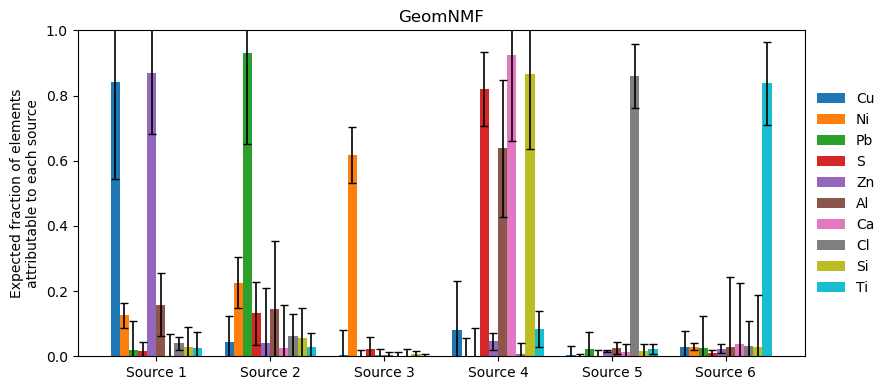

In [61]:
plot_C_mean_CI(Phi_hat[new_order,:], Phi_hat_stdlow[new_order,:], Phi_hat_stdhigh[new_order,:], col_label=col_label, 
               title="GeomNMF",
            #    savepath=outdir / f"figure/GL_scaled_K{K}_minK{min_K}_Phi_hat_bootCI.pdf", 
               figsize=(9, 4))

In [62]:
summary_phi = summarize_bootstrap_phi(results_all["Phi_hat"], tau=0.03)

In [63]:
summary_phi["cv_mean"]

0.09848396171903263

In [64]:
summary_phi["R"]

0.891

### N-FINDR

In [ ]:
Phi_hat_nfindr_stdlow = Phi_hat_nfindr - summary["nfindr"]["Phi_hat"]["std"].T
Phi_hat_nfindr_stdhigh = Phi_hat_nfindr + summary["nfindr"]["Phi_hat"]["std"].T

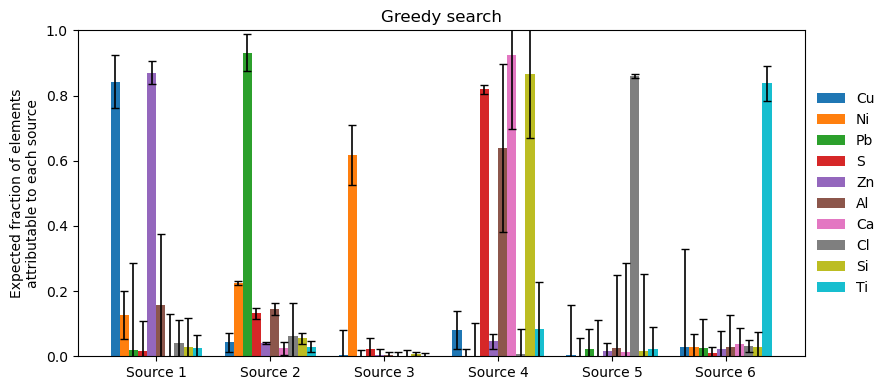

In [66]:
plot_C_mean_CI(Phi_hat_nfindr[new_order_nfindr,:], Phi_hat_nfindr_stdlow[new_order_nfindr,:], Phi_hat_nfindr_stdhigh[new_order_nfindr,:], col_label=col_label, 
               title="Greedy search",
            #    savepath=outdir / f"figure/GL_scaled_K{K}_minK{min_K}_Phi_hat_bootCI_nfindr.pdf", 
               figsize=(9, 4))

In [67]:
summary_phi_nfindr = summarize_bootstrap_phi(results_all["Phi_hat_nfindr"], tau=0.03)

In [68]:
summary_phi_nfindr["R"]

0.889

### LS-NMF

In [69]:
Phi_hat_lsnmf_stdlow = Phi_hat_lsnmf - summary["lsnmf"]["Phi_hat"]["std"].T
Phi_hat_lsnmf_stdhigh = Phi_hat_lsnmf + summary["lsnmf"]["Phi_hat"]["std"].T

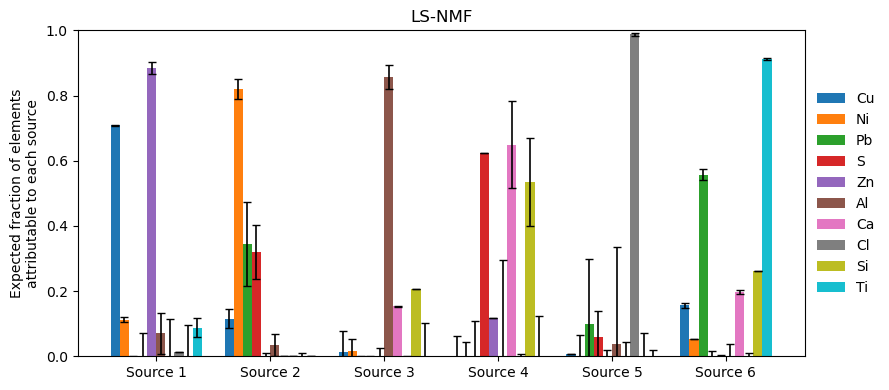

In [70]:
plot_C_mean_CI(Phi_hat_lsnmf[new_order_lsnmf,:], Phi_hat_lsnmf_stdlow[new_order_lsnmf,:], Phi_hat_lsnmf_stdhigh[new_order_lsnmf,:], 
               col_label=col_label, title = "LS-NMF", 
            #    savepath=outdir / f"figure/GL_scaled_K{K}_minK{min_K}_Phi_hat_bootCI_lsnmf.pdf", 
               figsize=(9, 4))

In [71]:
summary_phi_lsnmf = summarize_bootstrap_phi(results_all["Phi_hat_lsnmf"], tau=0.03)

In [72]:
summary_phi_lsnmf["R"]

0.915

### LS-NMF with regularization

In [73]:
Phi_hat_lsnmf_stdlow2 = Phi_hat_lsnmf2 - summary["lsnmf2"]["Phi_hat"]["std"].T
Phi_hat_lsnmf_stdhigh2 = Phi_hat_lsnmf2 + summary["lsnmf2"]["Phi_hat"]["std"].T

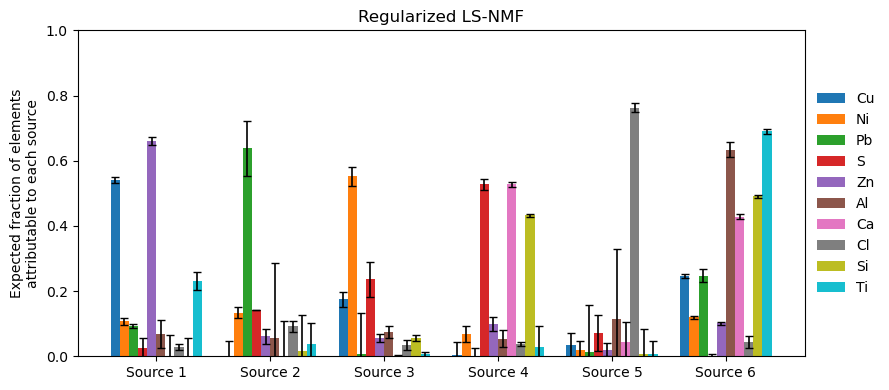

In [74]:
plot_C_mean_CI(Phi_hat_lsnmf2[new_order_lsnmf2,:], Phi_hat_lsnmf_stdlow2[new_order_lsnmf2,:], Phi_hat_lsnmf_stdhigh2[new_order_lsnmf2,:], 
               col_label=col_label, title = "Regularized LS-NMF", 
            #    savepath=outdir / f"figure/GL_scaled_K{K}_minK{min_K}_Phi_hat_bootCI_lsnmf2.pdf", 
               figsize=(9, 4))

In [75]:
summary_phi_lsnmf2 = summarize_bootstrap_phi(results_all["Phi_hat_lsnmf2"], tau=0.03)

In [76]:
summary_phi_lsnmf2["R"]

0.905

### PMF

In [77]:
Phi_hat_pmf_stdlow = Phi_hat_pmf - summary["pmf"]["Phi_hat"]["std"].T
Phi_hat_pmf_stdhigh = Phi_hat_pmf + summary["pmf"]["Phi_hat"]["std"].T

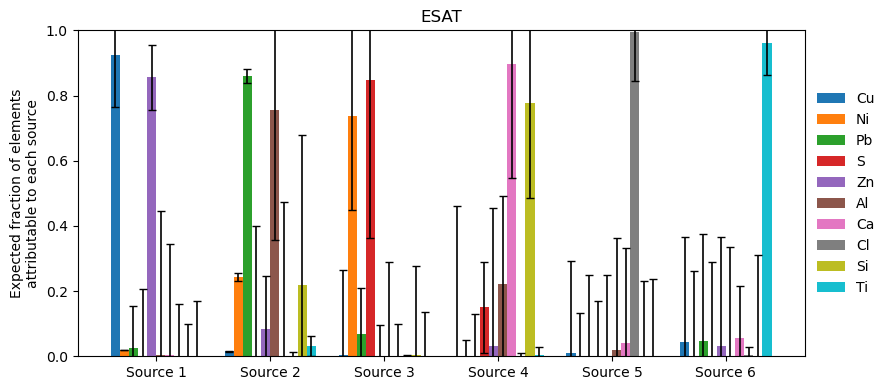

In [78]:
plot_C_mean_CI(Phi_hat_pmf[new_order_pmf,:], Phi_hat_pmf_stdlow[new_order_pmf,:], Phi_hat_pmf_stdhigh[new_order_pmf,:], 
               col_label=col_label, title = "ESAT", 
            #    savepath=outdir / f"figure/GL_scaled_K{K}_minK{min_K}_Phi_hat_bootCI_pmf.pdf", 
               figsize=(9, 4))

In [79]:
summary_phi_pmf = summarize_bootstrap_phi(results_all["Phi_hat_pmf"], tau=0.03)

In [80]:
summary_phi_pmf["R"]

0.7130000000000001

## Estimation results (K = 5)

In [89]:
K = 5
min_K = 20*K
H_star_hat, W_tilde_hat, mu_tilde_hat, C_hat, logvol_hat = load(outdir / f"GL_scaled_K{K}_minK{min_K}_results.joblib")
Phi_hat = C_hat.T
Yhat = W_tilde_hat @ H_star_hat

### GeomNMF

In [82]:
new_order = [3,2,0,1,4]

## Bootstrap uncertainty (K = 5)

In [88]:
lo, hi = 2.5, 97.5

summary = {}
for m in methods:
    method_label = m.lstrip("_") if m else "GeomNMF"
    summary[method_label] = {}
    for key in ["Phi_hat", "H_star_hat"]:
        arr = results_all[f"{key}{m}"]  # shape (n_reps, J, K) or (n_reps, K, J)
        summary[method_label][key] = {
            "mean": np.nanmean(arr, axis=0),
            "std": np.nanstd(arr, axis=0),
            "low":  np.nanpercentile(arr, lo, axis=0),
            "high": np.nanpercentile(arr, hi, axis=0),
        }

### GeomNMF

In [90]:
Phi_hat_stdlow = Phi_hat - summary["GeomNMF"]["Phi_hat"]["std"].T
Phi_hat_stdhigh = Phi_hat + summary["GeomNMF"]["Phi_hat"]["std"].T

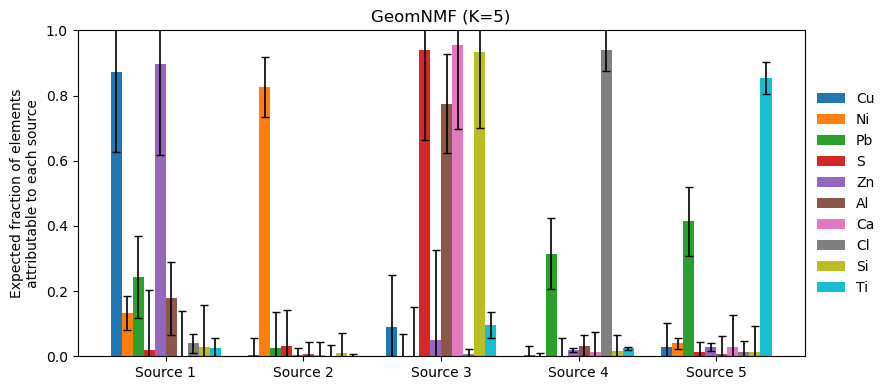

In [91]:
plot_C_mean_CI(Phi_hat[new_order,:], Phi_hat_stdlow[new_order,:], Phi_hat_stdhigh[new_order,:], col_label=col_label, 
               title="GeomNMF (K=5)",
            #    savepath=outdir / f"figure/GL_scaled_K{K}_minK{min_K}_Phi_hat_bootCI.pdf", 
               figsize=(9, 4))

In [92]:
summary_phi = summarize_bootstrap_phi(results_all["Phi_hat"], tau=0.03)

In [93]:
summary_phi["cv_mean"]

0.0899603210357516

In [94]:
summary_phi["R"]

0.8719999999999999